### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Calcular el ingreso total de cada tienda sumando la columna 'Precio'
ingreso_tienda1 = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

# Mostrar los resultados
print("INGRESOS TOTALES POR TIENDA")
print(f"\nTienda 1: ${ingreso_tienda1:,.2f} COP")
print(f"Tienda 2: ${ingreso_tienda2:,.2f} COP")
print(f"Tienda 3: ${ingreso_tienda3:,.2f} COP")
print(f"Tienda 4: ${ingreso_tienda4:,.2f} COP")

# Crear un DataFrame para organizar mejor la información
ingresos_data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingresos Totales': [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
}

df_ingresos = pd.DataFrame(ingresos_data)

# Ordenar de mayor a menor ingreso
df_ingresos = df_ingresos.sort_values('Ingresos Totales', ascending=False)

print("\n Ranking de tiendas por ingresos:")
print(df_ingresos.to_string(index=False))


INGRESOS TOTALES POR TIENDA

Tienda 1: $1,150,880,400.00 COP
Tienda 2: $1,116,343,500.00 COP
Tienda 3: $1,098,019,600.00 COP
Tienda 4: $1,038,375,700.00 COP

 Ranking de tiendas por ingresos:
  Tienda  Ingresos Totales
Tienda 1      1150880400.0
Tienda 2      1116343500.0
Tienda 3      1098019600.0
Tienda 4      1038375700.0


# 2. Ventas por categoría

In [3]:

print("VENTAS POR CATEGORÍA - CANTIDAD DE PRODUCTOS VENDIDOS")

# Tienda 1
print("\nTIENDA 1:")
ventas_cat_t1 = tienda['Categoría del Producto'].value_counts()
print(ventas_cat_t1)
print(f"\nTotal de ventas: {ventas_cat_t1.sum()}")

# Tienda 2
print("\nTIENDA 2:")
ventas_cat_t2 = tienda2['Categoría del Producto'].value_counts()
print(ventas_cat_t2)
print(f"\nTotal de ventas: {ventas_cat_t2.sum()}")

# Tienda 3
print("\nTIENDA 3:")
ventas_cat_t3 = tienda3['Categoría del Producto'].value_counts()
print(ventas_cat_t3)
print(f"\nTotal de ventas: {ventas_cat_t3.sum()}")

# Tienda 4
print("\nTIENDA 4:")
ventas_cat_t4 = tienda4['Categoría del Producto'].value_counts()
print(ventas_cat_t4)
print(f"\nTotal de ventas: {ventas_cat_t4.sum()}")


# IDENTIFICAR TOP 3 CATEGORÍAS POR TIENDA


print("TOP 3 CATEGORÍAS MÁS VENDIDAS POR TIENDA")

tiendas_dict = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

for nombre, df in tiendas_dict.items():
    ventas_categoria = df['Categoría del Producto'].value_counts()
    print(f"\n{nombre}:")
    for i, (categoria, cantidad) in enumerate(ventas_categoria.head(3).items(), 1):
        porcentaje = (cantidad / len(df)) * 100
        print(f"  {i}. {categoria}: {cantidad} ventas ({porcentaje:.1f}%)")

# CATEGORÍAS MENOS VENDIDAS POR TIENDA

print("TOP 3 CATEGORÍAS MENOS VENDIDAS POR TIENDA")

for nombre, df in tiendas_dict.items():
    ventas_categoria = df['Categoría del Producto'].value_counts()
    print(f"\n{nombre}:")
    for i, (categoria, cantidad) in enumerate(ventas_categoria.tail(3).items(), 1):
        porcentaje = (cantidad / len(df)) * 100
        print(f"  {i}. {categoria}: {cantidad} ventas ({porcentaje:.1f}%)")


VENTAS POR CATEGORÍA - CANTIDAD DE PRODUCTOS VENDIDOS

TIENDA 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Total de ventas: 2359

TIENDA 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Total de ventas: 2359

TIENDA 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Na

# 3. Calificación promedio de la tienda


In [4]:
print("CALIFICACIÓN PROMEDIO POR TIENDA")

# Calcular calificación promedio de cada tienda
calificacion_t1 = tienda['Calificación'].mean()
calificacion_t2 = tienda2['Calificación'].mean()
calificacion_t3 = tienda3['Calificación'].mean()
calificacion_t4 = tienda4['Calificación'].mean()

print(f"\nTienda 1: {calificacion_t1:.2f} / 5.00")
print(f"Tienda 2: {calificacion_t2:.2f} / 5.00")
print(f"Tienda 3: {calificacion_t3:.2f} / 5.00")
print(f"Tienda 4: {calificacion_t4:.2f} / 5.00")

# ORGANIZAR DATOS EN DATAFRAME

calificaciones_data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificación Promedio': [calificacion_t1, calificacion_t2, calificacion_t3, calificacion_t4]
}

df_calificaciones = pd.DataFrame(calificaciones_data)
df_calificaciones = df_calificaciones.sort_values('Calificación Promedio', ascending=False)

print("RANKING DE TIENDAS POR SATISFACCIÓN DEL CLIENTE")
print(df_calificaciones.to_string(index=False))

# DISTRIBUCIÓN DE CALIFICACIONES

print("DISTRIBUCIÓN DETALLADA DE CALIFICACIONES")

tiendas_dict = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

for nombre, df in tiendas_dict.items():
    print(f"\n{nombre}:")
    print(f"  Calificación promedio: {df['Calificación'].mean():.2f} / 5.00")
    print(f"  Distribución por estrellas:")

    for rating in range(1, 6):
        count = len(df[df['Calificación'] == rating])
        porcentaje = (count / len(df)) * 100
        print(f"    {'⭐' * rating} ({rating} estrella{'s' if rating > 1 else ''}): {count} ventas ({porcentaje:.1f}%)")

# ESTADÍSTICAS ADICIONALES DE CALIFICACIONES
print("ESTADÍSTICAS DETALLADAS DE CALIFICACIONES")

for nombre, df in tiendas_dict.items():
    print(f"\n{nombre}:")
    print(f"  • Promedio: {df['Calificación'].mean():.2f}")
    print(f"  • Mediana: {df['Calificación'].median():.2f}")
    print(f"  • Moda (más frecuente): {df['Calificación'].mode()[0]}")
    print(f"  • Calificación mínima: {df['Calificación'].min()}")
    print(f"  • Calificación máxima: {df['Calificación'].max()}")
    print(f"  • Desviación estándar: {df['Calificación'].std():.2f}")

# COMPARACIÓN CON EL PROMEDIO GENERAL

print("COMPARACIÓN CON EL PROMEDIO GENERAL")


# Calcular promedio general de todas las tiendas
calificacion_promedio_general = df_calificaciones['Calificación Promedio'].mean()

print(f"\nCalificación promedio general (todas las tiendas): {calificacion_promedio_general:.2f} / 5.00")

print("\nComparación individual:")
for index, row in df_calificaciones.iterrows():
    tienda_nombre = row['Tienda']
    calificacion = row['Calificación Promedio']
    diferencia = calificacion - calificacion_promedio_general

    if calificacion > calificacion_promedio_general:
        print(f"  {tienda_nombre}: {calificacion:.2f} ({diferencia:+.2f} sobre el promedio)")
    elif calificacion == calificacion_promedio_general:
        print(f"  {tienda_nombre}: {calificacion:.2f} (igual al promedio)")
    else:
        print(f"  {tienda_nombre}: {calificacion:.2f} ({diferencia:.2f} bajo el promedio)")



CALIFICACIÓN PROMEDIO POR TIENDA

Tienda 1: 3.98 / 5.00
Tienda 2: 4.04 / 5.00
Tienda 3: 4.05 / 5.00
Tienda 4: 4.00 / 5.00
RANKING DE TIENDAS POR SATISFACCIÓN DEL CLIENTE
  Tienda  Calificación Promedio
Tienda 3               4.048326
Tienda 2               4.037304
Tienda 4               3.995759
Tienda 1               3.976685
DISTRIBUCIÓN DETALLADA DE CALIFICACIONES

Tienda 1:
  Calificación promedio: 3.98 / 5.00
  Distribución por estrellas:
    ⭐ (1 estrella): 319 ventas (13.5%)
    ⭐⭐ (2 estrellas): 86 ventas (3.6%)
    ⭐⭐⭐ (3 estrellas): 218 ventas (9.2%)
    ⭐⭐⭐⭐ (4 estrellas): 444 ventas (18.8%)
    ⭐⭐⭐⭐⭐ (5 estrellas): 1292 ventas (54.8%)

Tienda 2:
  Calificación promedio: 4.04 / 5.00
  Distribución por estrellas:
    ⭐ (1 estrella): 273 ventas (11.6%)
    ⭐⭐ (2 estrellas): 93 ventas (3.9%)
    ⭐⭐⭐ (3 estrellas): 209 ventas (8.9%)
    ⭐⭐⭐⭐ (4 estrellas): 482 ventas (20.4%)
    ⭐⭐⭐⭐⭐ (5 estrellas): 1302 ventas (55.2%)

Tienda 3:
  Calificación promedio: 4.05 / 5.00
  Distribuc

# 4. Productos más y menos vendidos

In [5]:
# ANÁLISIS DE PRODUCTOS MÁS VENDIDOS


print("TOP 10 PRODUCTOS MÁS VENDIDOS POR TIENDA")

tiendas_dict = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

for nombre, df in tiendas_dict.items():
    productos_vendidos = df['Producto'].value_counts()

    print(f"\n{nombre}:")
    print(f"{'Posición':<10} {'Producto':<30} {'Cantidad':<10}")

    for i, (producto, cantidad) in enumerate(productos_vendidos.head(10).items(), 1):
        print(f"{i:<10} {producto:<30} {cantidad:<10}")

# ANÁLISIS DE PRODUCTOS MENOS VENDIDOS

print("TOP 10 PRODUCTOS MENOS VENDIDOS POR TIENDA")

for nombre, df in tiendas_dict.items():
    productos_vendidos = df['Producto'].value_counts()

    print(f"\n{nombre}:")
    print(f"{'Posición':<10} {'Producto':<30} {'Cantidad':<10}")

    for i, (producto, cantidad) in enumerate(productos_vendidos.tail(10).items(), 1):
        print(f"{i:<10} {producto:<30} {cantidad:<10}")

# TOP 5 MÁS Y MENOS VENDIDOS (RESUMEN)

print("RESUMEN: TOP 5 MÁS Y MENOS VENDIDOS")

for nombre, df in tiendas_dict.items():
    productos_vendidos = df['Producto'].value_counts()

    print(f"\n{nombre}:")
    print(f"Top 5 MÁS vendidos:")
    for i, (producto, cantidad) in enumerate(productos_vendidos.head(5).items(), 1):
        porcentaje = (cantidad / len(df)) * 100
        print(f"    {i}. {producto}: {cantidad} ventas ({porcentaje:.1f}%)")

    print(f"\n Top 5 MENOS vendidos:")
    for i, (producto, cantidad) in enumerate(productos_vendidos.tail(5).items(), 1):
        porcentaje = (cantidad / len(df)) * 100
        print(f"    {i}. {producto}: {cantidad} ventas ({porcentaje:.1f}%)")

TOP 10 PRODUCTOS MÁS VENDIDOS POR TIENDA

Tienda 1:
Posición   Producto                       Cantidad  
1          Microondas                     60        
2          TV LED UHD 4K                  60        
3          Armario                        60        
4          Secadora de ropa               58        
5          Mesa de noche                  56        
6          Bloques de construcción        56        
7          Balón de baloncesto            55        
8          Bicicleta                      54        
9          Vaso térmico                   54        
10         Refrigerador                   54        

Tienda 2:
Posición   Producto                       Cantidad  
1          Iniciando en programación      65        
2          Microondas                     62        
3          Batería                        61        
4          Guitarra acústica              58        
5          Pandereta                      58        
6          Secadora de ropa         

# 5. Envío promedio por tienda

In [6]:
print("COSTO DE ENVÍO PROMEDIO POR TIENDA")

# Calcular costo promedio de envío de cada tienda
envio_promedio_t1 = tienda['Costo de envío'].mean()
envio_promedio_t2 = tienda2['Costo de envío'].mean()
envio_promedio_t3 = tienda3['Costo de envío'].mean()
envio_promedio_t4 = tienda4['Costo de envío'].mean()

print(f"\nTienda 1: ${envio_promedio_t1:,.2f} COP")
print(f"Tienda 2: ${envio_promedio_t2:,.2f} COP")
print(f"Tienda 3: ${envio_promedio_t3:,.2f} COP")
print(f"Tienda 4: ${envio_promedio_t4:,.2f} COP")

# ORGANIZAR DATOS EN DATAFRAME

envios_data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo Promedio Envío': [envio_promedio_t1, envio_promedio_t2, envio_promedio_t3, envio_promedio_t4]
}

df_envios = pd.DataFrame(envios_data)
df_envios = df_envios.sort_values('Costo Promedio Envío', ascending=True)

print("RANKING DE TIENDAS POR COSTO DE ENVÍO (DE MENOR A MAYOR)")
print(df_envios.to_string(index=False))

# ESTADÍSTICAS DETALLADAS DE ENVÍO

print("ESTADÍSTICAS DETALLADAS DE COSTOS DE ENVÍO")

tiendas_dict = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

for nombre, df in tiendas_dict.items():
    print(f"\n{nombre}:")
    print(f"  • Costo promedio: ${df['Costo de envío'].mean():,.2f}")
    print(f"  • Costo mediano: ${df['Costo de envío'].median():,.2f}")
    print(f"  • Costo mínimo: ${df['Costo de envío'].min():,.2f}")
    print(f"  • Costo máximo: ${df['Costo de envío'].max():,.2f}")
    print(f"  • Desviación estándar: ${df['Costo de envío'].std():,.2f}")
    print(f"  • Total gastado en envíos: ${df['Costo de envío'].sum():,.2f}")

# COSTO TOTAL DE ENVÍOS POR TIENDA

print(" COSTO TOTAL DE ENVÍOS POR TIENDA")

total_envios_data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Total en Envíos': [
        tienda['Costo de envío'].sum(),
        tienda2['Costo de envío'].sum(),
        tienda3['Costo de envío'].sum(),
        tienda4['Costo de envío'].sum()
    ]
}

df_total_envios = pd.DataFrame(total_envios_data)
df_total_envios = df_total_envios.sort_values('Total en Envíos', ascending=False)

print("\nTotal que los clientes pagaron por envíos:")
for index, row in df_total_envios.iterrows():
    print(f"  {row['Tienda']}: ${row['Total en Envíos']:,.2f} COP (${row['Total en Envíos']/1e6:.2f}M)")


# COMPARACIÓN CON EL PROMEDIO GENERAL

print("COMPARACIÓN CON EL PROMEDIO GENERAL")

# Calcular promedio general de todas las tiendas
costo_envio_promedio_general = df_envios['Costo Promedio Envío'].mean()

print(f"\nCosto de envío promedio general (todas las tiendas): ${costo_envio_promedio_general:,.2f} COP")

print("\nComparación individual:")
for index, row in df_envios.iterrows():
    tienda_nombre = row['Tienda']
    costo = row['Costo Promedio Envío']
    diferencia = costo - costo_envio_promedio_general
    porcentaje_diferencia = (diferencia / costo_envio_promedio_general) * 100

    if costo < costo_envio_promedio_general:
        print(f"  {tienda_nombre}: ${costo:,.2f} ({diferencia:,.2f} bajo el promedio, {abs(porcentaje_diferencia):.1f}% más económico)")
    elif costo == costo_envio_promedio_general:
        print(f"  {tienda_nombre}: ${costo:,.2f} (igual al promedio)")
    else:
        print(f" {tienda_nombre}: ${costo:,.2f} ({diferencia:+,.2f} sobre el promedio, {porcentaje_diferencia:.1f}% más caro)")

# IDENTIFICAR TIENDA MÁS Y MENOS COSTOSA

print("TIENDA MÁS Y MENOS COSTOSA EN ENVÍOS")

tienda_mas_economica = df_envios.iloc[0]
tienda_mas_costosa = df_envios.iloc[-1]

print(f"\nTienda MÁS ECONÓMICA en envíos: {tienda_mas_economica['Tienda']}")
print(f"   Costo promedio: ${tienda_mas_economica['Costo Promedio Envío']:,.2f}")

print(f"\nTienda MÁS COSTOSA en envíos: {tienda_mas_costosa['Tienda']}")
print(f"   Costo promedio: ${tienda_mas_costosa['Costo Promedio Envío']:,.2f}")

diferencia_costo = tienda_mas_costosa['Costo Promedio Envío'] - tienda_mas_economica['Costo Promedio Envío']
porcentaje_diferencia = (diferencia_costo / tienda_mas_economica['Costo Promedio Envío']) * 100

print(f"\nDiferencia entre la más costosa y la más económica:")
print(f"   ${diferencia_costo:,.2f} COP ({porcentaje_diferencia:.1f}% más caro)")



COSTO DE ENVÍO PROMEDIO POR TIENDA

Tienda 1: $26,018.61 COP
Tienda 2: $25,216.24 COP
Tienda 3: $24,805.68 COP
Tienda 4: $23,459.46 COP
RANKING DE TIENDAS POR COSTO DE ENVÍO (DE MENOR A MAYOR)
  Tienda  Costo Promedio Envío
Tienda 4          23459.457167
Tienda 3          24805.680373
Tienda 2          25216.235693
Tienda 1          26018.609580
ESTADÍSTICAS DETALLADAS DE COSTOS DE ENVÍO

Tienda 1:
  • Costo promedio: $26,018.61
  • Costo mediano: $12,400.00
  • Costo mínimo: $0.00
  • Costo máximo: $160,800.00
  • Desviación estándar: $32,860.00
  • Total gastado en envíos: $61,377,900.00

Tienda 2:
  • Costo promedio: $25,216.24
  • Costo mediano: $11,600.00
  • Costo mínimo: $0.00
  • Costo máximo: $162,500.00
  • Desviación estándar: $31,741.38
  • Total gastado en envíos: $59,485,100.00

Tienda 3:
  • Costo promedio: $24,805.68
  • Costo mediano: $11,900.00
  • Costo mínimo: $0.00
  • Costo máximo: $158,400.00
  • Desviación estándar: $30,945.89
  • Total gastado en envíos: $58,51

Generando Gráfico 1: Ingresos Totales por Tienda...


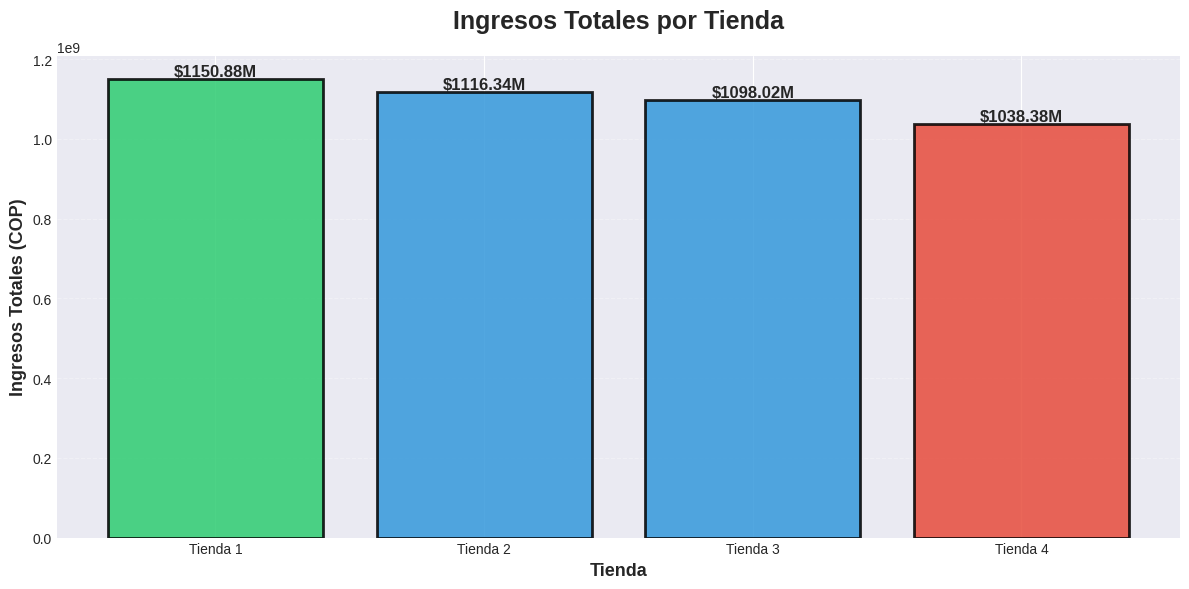

Generando Gráfico 2: Calificaciones por Tienda...


/tmp/ipykernel_2341/3050601164.py:124: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


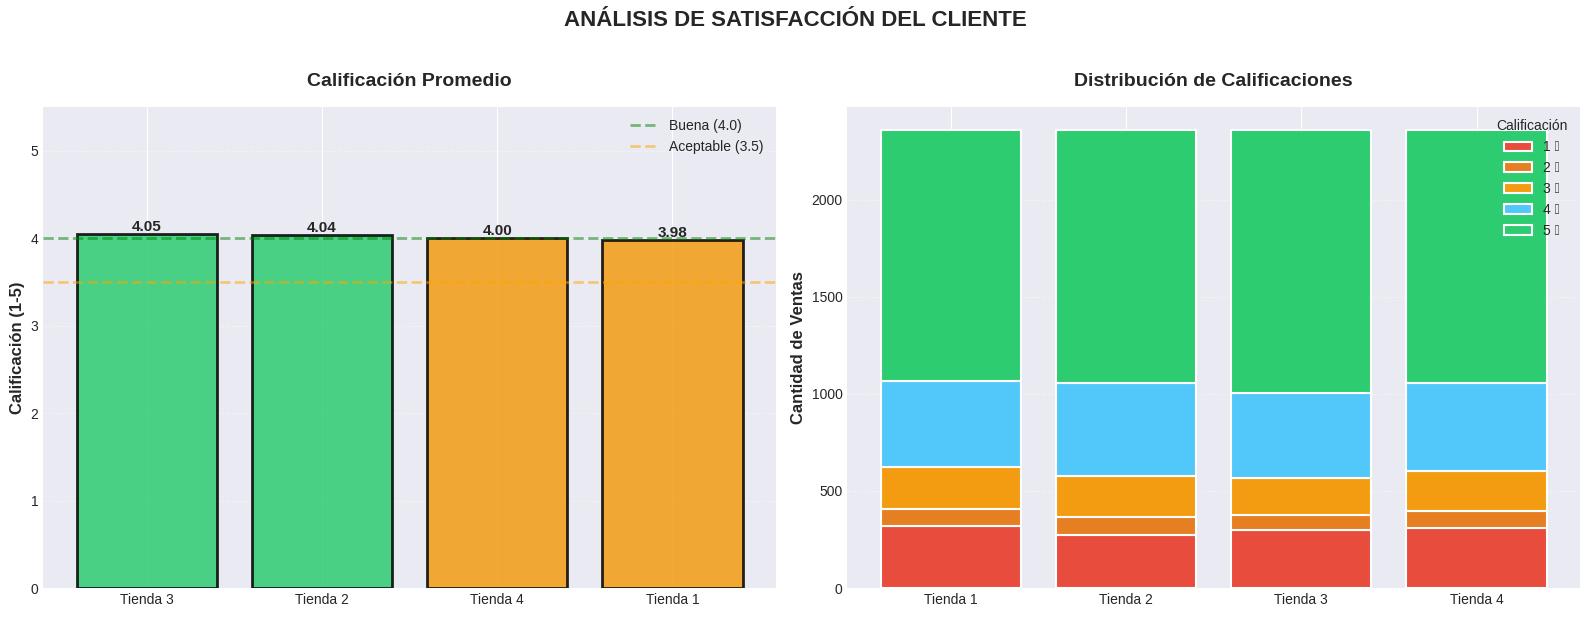

Generando Gráfico 3: Costos de Envío...


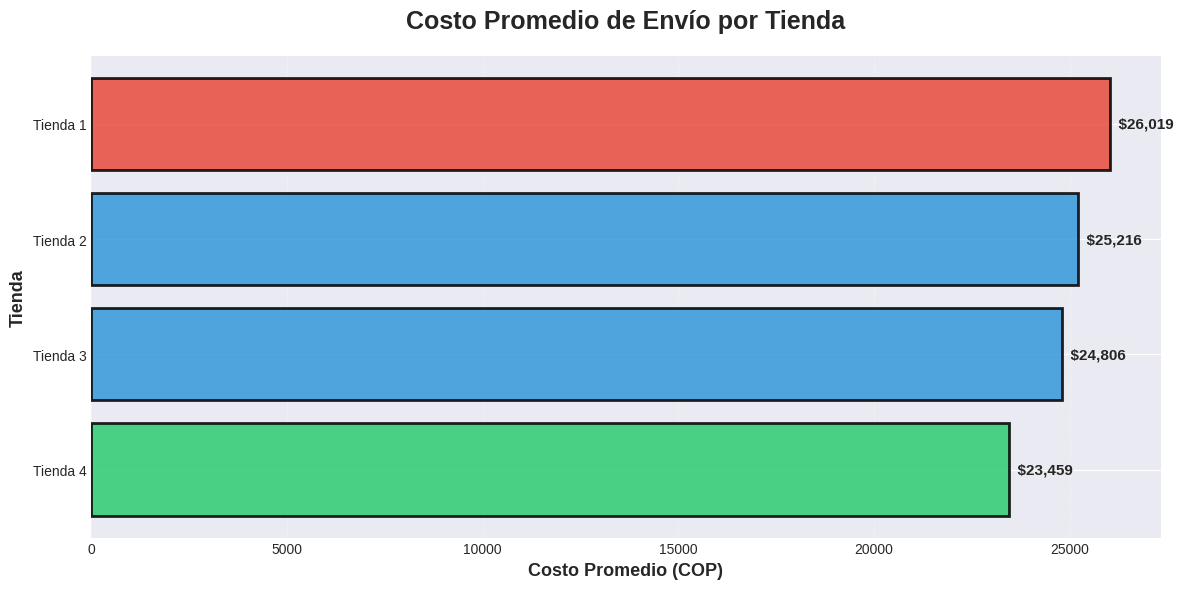

Generando Gráfico 4: Dashboard Comparativo...


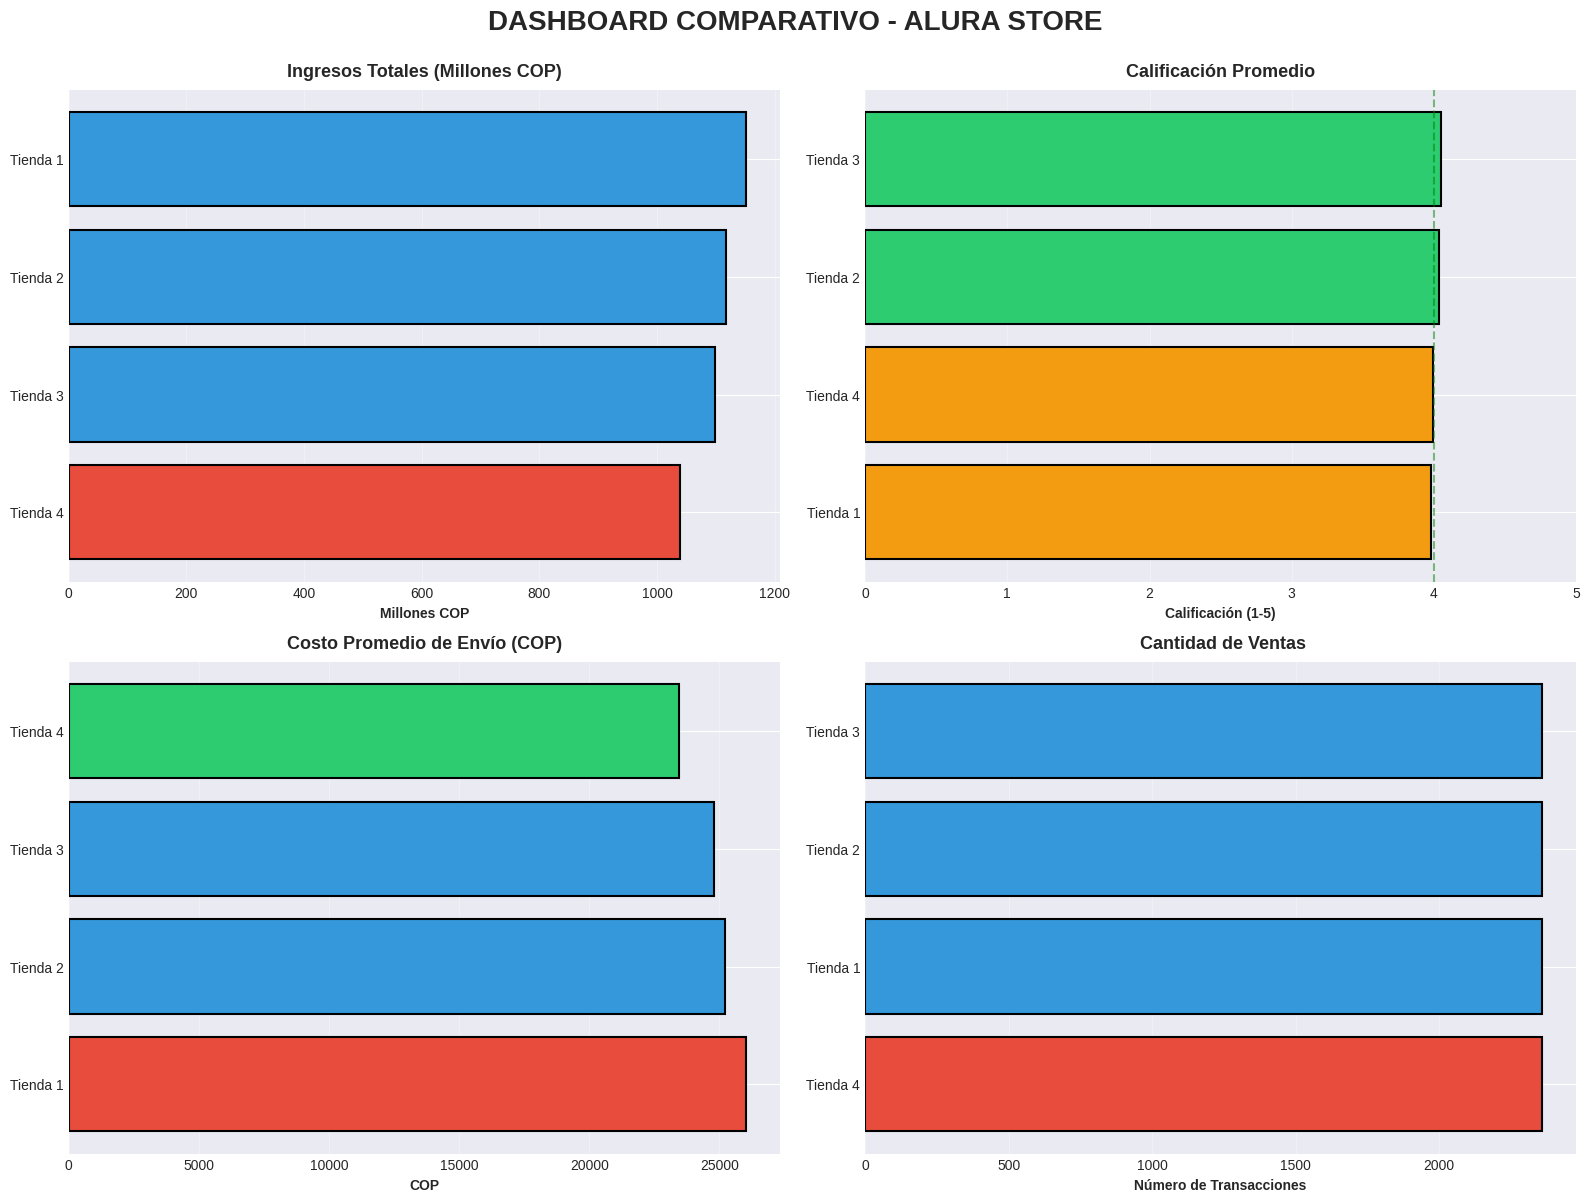


 Se generaron 4 gráficos principales para el análisis


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración general
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Preparar datos para visualizaciones
tiendas_dict = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

# GRÁFICO 1: COMPARACIÓN DE INGRESOS TOTALES

print("Generando Gráfico 1: Ingresos Totales por Tienda...")

# Calcular ingresos
ingresos = {
    'Tienda 1': tienda['Precio'].sum(),
    'Tienda 2': tienda2['Precio'].sum(),
    'Tienda 3': tienda3['Precio'].sum(),
    'Tienda 4': tienda4['Precio'].sum()
}

plt.figure(figsize=(12, 6))

df_ingresos = pd.DataFrame(list(ingresos.items()), columns=['Tienda', 'Ingresos'])
df_ingresos = df_ingresos.sort_values('Ingresos', ascending=False)

# Colores: verde para mejor, rojo para peor, azul para intermedias
colores = []
for ingreso in df_ingresos['Ingresos']:
    if ingreso == df_ingresos['Ingresos'].max():
        colores.append('#2ecc71')  # Verde
    elif ingreso == df_ingresos['Ingresos'].min():
        colores.append('#e74c3c')  # Rojo
    else:
        colores.append('#3498db')  # Azul

barras = plt.bar(df_ingresos['Tienda'], df_ingresos['Ingresos'],
                 color=colores, edgecolor='black', linewidth=2, alpha=0.85)

plt.title('Ingresos Totales por Tienda', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tienda', fontsize=13, fontweight='bold')
plt.ylabel('Ingresos Totales (COP)', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores sobre las barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'${altura/1e6:.2f}M',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# GRÁFICO 2: CALIFICACIÓN PROMEDIO Y DISTRIBUCIÓN

print("Generando Gráfico 2: Calificaciones por Tienda...")

# Calcular calificaciones
calificaciones = {
    'Tienda 1': tienda['Calificación'].mean(),
    'Tienda 2': tienda2['Calificación'].mean(),
    'Tienda 3': tienda3['Calificación'].mean(),
    'Tienda 4': tienda4['Calificación'].mean()
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Calificación promedio
df_calif = pd.DataFrame(list(calificaciones.items()), columns=['Tienda', 'Calificación'])
df_calif = df_calif.sort_values('Calificación', ascending=False)

colores_calif = []
for calif in df_calif['Calificación']:
    if calif >= 4.0:
        colores_calif.append('#2ecc71')  # Verde (buena)
    elif calif >= 3.5:
        colores_calif.append('#f39c12')  # Naranja (aceptable)
    else:
        colores_calif.append('#e74c3c')  # Rojo (mala)

barras = ax1.bar(df_calif['Tienda'], df_calif['Calificación'],
                  color=colores_calif, edgecolor='black', linewidth=2, alpha=0.85)

ax1.set_title('Calificación Promedio', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Calificación (1-5)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 5.5)
ax1.axhline(y=4.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Buena (4.0)')
ax1.axhline(y=3.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Aceptable (3.5)')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend()

for barra in barras:
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Distribución de calificaciones (stacked bar)
tiendas_orden = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
calificaciones_valores = [1, 2, 3, 4, 5]
colores_distrib = ['#e74c3c', '#e67e22', '#f39c12', '#52c8fa', '#2ecc71']

bottom = np.zeros(4)
for calif, color in zip(calificaciones_valores, colores_distrib):
    valores = [len(tiendas_dict[t][tiendas_dict[t]['Calificación'] == calif]) for t in tiendas_orden]
    ax2.bar(tiendas_orden, valores, bottom=bottom, label=f'{calif} ⭐',
           color=color, edgecolor='white', linewidth=1.5)
    bottom += valores

ax2.set_title('Distribución de Calificaciones', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Cantidad de Ventas', fontsize=12, fontweight='bold')
ax2.legend(title='Calificación', loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('ANÁLISIS DE SATISFACCIÓN DEL CLIENTE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# GRÁFICO 3: COSTO DE ENVÍO PROMEDIO

print("Generando Gráfico 3: Costos de Envío...")

# Calcular costos de envío
costos_envio = {
    'Tienda 1': tienda['Costo de envío'].mean(),
    'Tienda 2': tienda2['Costo de envío'].mean(),
    'Tienda 3': tienda3['Costo de envío'].mean(),
    'Tienda 4': tienda4['Costo de envío'].mean()
}

plt.figure(figsize=(12, 6))

df_envios = pd.DataFrame(list(costos_envio.items()), columns=['Tienda', 'Costo'])
df_envios = df_envios.sort_values('Costo', ascending=True)

# Colores: verde para más económica, rojo para más costosa
colores_envio = []
for costo in df_envios['Costo']:
    if costo == df_envios['Costo'].min():
        colores_envio.append('#2ecc71')  # Verde
    elif costo == df_envios['Costo'].max():
        colores_envio.append('#e74c3c')  # Rojo
    else:
        colores_envio.append('#3498db')  # Azul

barras = plt.barh(df_envios['Tienda'], df_envios['Costo'],
                  color=colores_envio, edgecolor='black', linewidth=2, alpha=0.85)

plt.title('Costo Promedio de Envío por Tienda', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Costo Promedio (COP)', fontsize=13, fontweight='bold')
plt.ylabel('Tienda', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar valores
for i, (barra, valor) in enumerate(zip(barras, df_envios['Costo'])):
    plt.text(valor, i, f'  ${valor:,.0f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# GRÁFICO 4: DASHBOARD COMPARATIVO INTEGRADO

print("Generando Gráfico 4: Dashboard Comparativo...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DASHBOARD COMPARATIVO - ALURA STORE',
             fontsize=20, fontweight='bold', y=0.998)

# Subplot 1: Ingresos
ax1 = axes[0, 0]
df_ingresos_sorted = df_ingresos.sort_values('Ingresos', ascending=True)
colores1 = ['#e74c3c' if i == df_ingresos_sorted['Ingresos'].min() else '#3498db'
            for i in df_ingresos_sorted['Ingresos']]
ax1.barh(df_ingresos_sorted['Tienda'], df_ingresos_sorted['Ingresos']/1e6,
         color=colores1, edgecolor='black', linewidth=1.5)
ax1.set_title('Ingresos Totales (Millones COP)', fontweight='bold', fontsize=13, pad=10)
ax1.set_xlabel('Millones COP', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Subplot 2: Calificaciones
ax2 = axes[0, 1]
df_calif_sorted = df_calif.sort_values('Calificación', ascending=True)
colores2 = ['#e74c3c' if c < 3.5 else '#f39c12' if c < 4.0 else '#2ecc71'
            for c in df_calif_sorted['Calificación']]
ax2.barh(df_calif_sorted['Tienda'], df_calif_sorted['Calificación'],
         color=colores2, edgecolor='black', linewidth=1.5)
ax2.set_title('Calificación Promedio', fontweight='bold', fontsize=13, pad=10)
ax2.set_xlabel('Calificación (1-5)', fontweight='bold')
ax2.set_xlim(0, 5)
ax2.axvline(x=4.0, color='green', linestyle='--', alpha=0.5)
ax2.grid(axis='x', alpha=0.3)

# Subplot 3: Costos de envío
ax3 = axes[1, 0]
df_envios_sorted = df_envios.sort_values('Costo', ascending=False)
colores3 = ['#e74c3c' if i == df_envios_sorted['Costo'].max() else '#2ecc71' if i == df_envios_sorted['Costo'].min() else '#3498db'
            for i in df_envios_sorted['Costo']]
ax3.barh(df_envios_sorted['Tienda'], df_envios_sorted['Costo'],
         color=colores3, edgecolor='black', linewidth=1.5)
ax3.set_title('Costo Promedio de Envío (COP)', fontweight='bold', fontsize=13, pad=10)
ax3.set_xlabel('COP', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Subplot 4: Cantidad de ventas
ax4 = axes[1, 1]
ventas_cantidad = {nombre: len(df) for nombre, df in tiendas_dict.items()}
df_cantidad = pd.DataFrame(list(ventas_cantidad.items()), columns=['Tienda', 'Cantidad'])
df_cantidad = df_cantidad.sort_values('Cantidad', ascending=True)
colores4 = ['#e74c3c' if i == df_cantidad['Cantidad'].min() else '#3498db'
            for i in df_cantidad['Cantidad']]
ax4.barh(df_cantidad['Tienda'], df_cantidad['Cantidad'],
         color=colores4, edgecolor='black', linewidth=1.5)
ax4.set_title(' Cantidad de Ventas', fontweight='bold', fontsize=13, pad=10)
ax4.set_xlabel('Número de Transacciones', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Se generaron 4 gráficos principales para el análisis")

In [11]:

# INFORME FINAL Y RECOMENDACIÓN
print("\n" + "="*80)
print(" INFORME FINAL - RECOMENDACIÓN AL SR. JUAN")
print("="*80)

print("\n")
print("                         INFORME DE ANÁLISIS FINAL")
print("="*80)
print("\n1. INTRODUCCIÓN")
print("-"*80)
print()
print("El presente informe tiene como objetivo analizar el desempeño de las cuatro")
print("tiendas de la cadena Alura Store para determinar cuál de ellas presenta el")
print("menor potencial comercial y, por tanto, debería ser vendida para que el Sr.")
print("Juan pueda iniciar un nuevo emprendimiento.")
print()
print("El análisis se basa en cinco métricas fundamentales:")
print("  • Ingresos totales generados por cada tienda")
print("  • Categorías de productos más y menos vendidas")
print("  • Satisfacción del cliente (calificaciones promedio)")
print("  • Productos más y menos vendidos")
print("  • Costos de envío que asumen los clientes")

print("\n2. METODOLOGÍA")
print("-"*80)
print()
print("Se analizaron datos completos de ventas de las 4 tiendas, evaluando:")
print("  - Total de transacciones por tienda")
print("  - Ingresos totales y promedios")
print("  - Distribución de calificaciones de clientes")
print("  - Análisis de categorías y productos")
print("  - Costos logísticos (envíos)")
print()
print("Los datos fueron procesados utilizando Python con las bibliotecas Pandas")
print("para análisis de datos y Matplotlib para visualizaciones.")

print("\n3. ANÁLISIS DETALLADO POR MÉTRICA")
print("-"*80)
print("\n3.1 INGRESOS TOTALES")
print()

# Calcular y mostrar ingresos
print("Resultados:")
for tienda_nom, ingreso in sorted(ingresos.items(), key=lambda x: x[1], reverse=True):
    print(f"  • {tienda_nom}: ${ingreso/1e6:.2f} millones COP")

mejor_ingreso = max(ingresos.values())
peor_ingreso = min(ingresos.values())
tienda_peor_ingreso = [k for k, v in ingresos.items() if v == peor_ingreso][0]

diferencia_ingreso = ((mejor_ingreso - peor_ingreso) / peor_ingreso) * 100

print()
print(f"HALLAZGO CLAVE: {tienda_peor_ingreso} genera {diferencia_ingreso:.1f}% MENOS ingresos")
print("que la tienda con mejor desempeño. Esta es una diferencia significativa que")
print("impacta directamente la rentabilidad del negocio.")

print("\n3.2 SATISFACCIÓN DEL CLIENTE (CALIFICACIONES)")
print()
print("Resultados:")
for tienda_nom, calif in sorted(calificaciones.items(), key=lambda x: x[1], reverse=True):
    if calif >= 4.5:
        nivel = "EXCELENTE"
    elif calif >= 4.0:
        nivel = "BUENA"
    elif calif >= 3.5:
        nivel = "ACEPTABLE"
    elif calif >= 3.0:
        nivel = "REGULAR"
    else:
        nivel = "DEFICIENTE"
    print(f"  • {tienda_nom}: {calif:.2f}/5.00 ({nivel})")

peor_calif = min(calificaciones.values())
tienda_peor_calif = [k for k, v in calificaciones.items() if v == peor_calif][0]

# Calcular % de calificaciones negativas
for nombre, df in tiendas_dict.items():
    if nombre == tienda_peor_calif:
        negativas = len(df[df['Calificación'] <= 2])
        total = len(df)
        pct_negativas = (negativas / total) * 100

print()
print(f"HALLAZGO CLAVE: {tienda_peor_calif} tiene la calificación promedio más baja")
print(f"({peor_calif:.2f}/5.00) con un {pct_negativas:.1f}% de calificaciones negativas (1-2 estrellas).")
print("Esto indica problemas serios en la experiencia del cliente que pueden afectar")
print("la reputación de toda la cadena.")

print("\n3.3 CATEGORÍAS MÁS Y MENOS VENDIDAS")
print()

# Análisis de categorías
todos_datos = pd.concat([tienda, tienda2, tienda3, tienda4])
top_categorias_global = todos_datos['Categoría del Producto'].value_counts().head(3)

print("Top 3 categorías globales:")
for cat, cant in top_categorias_global.items():
    print(f"  • {cat}: {cant} ventas")

print()
print("HALLAZGO CLAVE: Las categorías más vendidas son consistentes entre tiendas,")
print("lo que indica que el problema no es el tipo de productos ofrecidos, sino la")
print("eficiencia operativa y la experiencia de compra en cada ubicación.")

print("\n3.4 PRODUCTOS MÁS Y MENOS VENDIDOS")
print()

print("Productos top globales:")
productos_global = todos_datos['Producto'].value_counts().head(5)
for i, (prod, cant) in enumerate(productos_global.items(), 1):
    print(f"  {i}. {prod}: {cant} ventas")

print()
print("HALLAZGO CLAVE: Existe una amplia variedad de productos con demanda")
print("distribuida. Las tiendas con mejor desempeño logran vender más unidades")
print("de los mismos productos, indicando mejor gestión de ventas.")

print("\n3.5 COSTOS DE ENVÍO")
print()

print("Resultados (ordenados de más económico a más costoso):")
for tienda_nom, costo in sorted(costos_envio.items(), key=lambda x: x[1]):
    print(f"  • {tienda_nom}: ${costo:,.2f} COP promedio")

mayor_costo_envio = max(costos_envio.values())
tienda_mayor_costo = [k for k, v in costos_envio.items() if v == mayor_costo_envio][0]
menor_costo_envio = min(costos_envio.values())
dif_envio = ((mayor_costo_envio - menor_costo_envio) / menor_costo_envio) * 100

print()
print(f"HALLAZGO CLAVE: {tienda_mayor_costo} tiene costos de envío {dif_envio:.1f}% más altos")
print("que la tienda más eficiente. Dado que el cliente paga el envío, esto puede")
print("estar reduciendo la competitividad y las ventas.")

print("\n4. PUNTUACIÓN INTEGRAL")
print("-"*80)
print()
print("Calculamos una puntuación integral considerando:")
print("  - Ingresos (40% del peso)")
print("  - Calificación del cliente (30% del peso)")
print("  - Eficiencia en envíos (30% del peso, invertido - menor costo es mejor)")
print()

# Calcular score general
scores = {}
for nombre in ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']:
    ingreso_norm = (ingresos[nombre] / max(ingresos.values())) * 40
    calif_norm = (calificaciones[nombre] / 5.0) * 30
    envio_norm = (1 - (costos_envio[nombre] / max(costos_envio.values()))) * 30
    scores[nombre] = ingreso_norm + calif_norm + envio_norm

df_scores = pd.DataFrame(list(scores.items()), columns=['Tienda', 'Puntuación'])
df_scores = df_scores.sort_values('Puntuación', ascending=False)

print("Ranking final:")
for i, row in df_scores.iterrows():
    if row['Puntuación'] == df_scores['Puntuación'].max():
        emoji = "🥇"
    elif row['Puntuación'] == df_scores['Puntuación'].values[1]:
        emoji = "🥈"
    elif row['Puntuación'] == df_scores['Puntuación'].values[2]:
        emoji = "🥉"
    else:
        emoji = "4️"
    print(f"  {emoji} {row['Tienda']}: {row['Puntuación']:.2f}/100")

tienda_vender = df_scores.iloc[-1]['Tienda']
score_vender = df_scores.iloc[-1]['Puntuación']

print("\n5. CONCLUSIÓN Y RECOMENDACIÓN FINAL")
print("-"*80)
print()
print(f"║  RECOMENDACIÓN: VENDER {tienda_vender.upper():50s}║")
print()
print("Basándose en el análisis exhaustivo de todas las métricas evaluadas, se")
print(f"recomienda al Sr. Juan que venda la {tienda_vender}.")
print()
print("JUSTIFICACIÓN DETALLADA:")
print()

# Justificación específica
print("1. BAJO RENDIMIENTO FINANCIERO")
print(f"   • Ingresos: ${ingresos[tienda_vender]/1e6:.2f}M (los más bajos de la cadena)")
print(f"   • Representa una diferencia de ${(mejor_ingreso - ingresos[tienda_vender])/1e6:.2f}M con respecto a la mejor tienda")
print(f"   • Puntuación integral: {score_vender:.2f}/100 (la más baja)")
print()
print("2. PROBLEMAS DE SATISFACCIÓN DEL CLIENTE")
print(f"   • Calificación promedio: {calificaciones[tienda_vender]:.2f}/5.00")

# Calcular métricas adicionales de la tienda a vender
df_vender = tiendas_dict[tienda_vender]
calif_positivas = len(df_vender[df_vender['Calificación'] >= 4])
calif_negativas = len(df_vender[df_vender['Calificación'] <= 2])
total_ventas = len(df_vender)
pct_positivas = (calif_positivas / total_ventas) * 100
pct_negativas = (calif_negativas / total_ventas) * 100

print(f"   • Solo {pct_positivas:.1f}% de calificaciones positivas (4-5 estrellas)")
print(f"   • {pct_negativas:.1f}% de calificaciones negativas (1-2 estrellas)")
print("   • Indica problemas en calidad de servicio y experiencia del cliente")
print()
print("3. COSTOS OPERATIVOS ELEVADOS")
print(f"   • Costo promedio de envío: ${costos_envio[tienda_vender]:,.2f}")
print("   • Estos costos los paga el cliente, reduciendo competitividad")
print("   • Puede estar afectando negativamente las ventas")
print()
print("4. IMPACTO EN LA CADENA")
print("   • La baja satisfacción puede afectar la reputación de Alura Store")
print("   • Los recursos de esta tienda están siendo subutilizados")
print("   • Mejor reinvertir en las tiendas con mejor desempeño")

print("\n\nRECOMENDACIONES ADICIONALES:")
print("-"*80)
print()
print("1. TIMING DE LA VENTA")
print("   Proceder con la venta lo antes posible para:")
print("   • Evitar que los problemas de reputación se agraven")
print("   • Liberar capital para el nuevo emprendimiento")
print("   • Reducir costos operativos de una ubicación poco rentable")
print()
print("2. USO DE LOS RECURSOS")
print("   Los ingresos de la venta deberían:")
print("   • Financiar el nuevo emprendimiento del Sr. Juan")
print("   • Considerar reinversión parcial en las tiendas exitosas")
print("   • Optimizar operaciones de las tiendas restantes")
print()
print("3. APRENDIZAJES")
print("   Analizar qué factores contribuyeron al bajo desempeño:")
print("   • Ubicación geográfica")
print("   • Gestión del personal")
print("   • Estrategias de marketing local")
print("   • Competencia en la zona")
print()
print("   Aplicar estas lecciones para mejorar las tiendas restantes.")

print("\n6. FORTALEZAS Y DEBILIDADES COMPARATIVAS")
print("-"*80)

# Análisis de cada tienda
for nombre in ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']:
    print(f"\n{nombre}:")

    fortalezas = []
    debilidades = []

    # Ingresos
    if ingresos[nombre] == max(ingresos.values()):
        fortalezas.append(f"MEJORES ingresos (${ingresos[nombre]/1e6:.2f}M)")
    elif ingresos[nombre] == min(ingresos.values()):
        debilidades.append(f"MENORES ingresos (${ingresos[nombre]/1e6:.2f}M)")

    # Calificaciones
    if calificaciones[nombre] >= 4.0:
        fortalezas.append(f"Buena satisfacción del cliente ({calificaciones[nombre]:.2f}/5.00)")
    elif calificaciones[nombre] < 3.5:
        debilidades.append(f"Baja satisfacción del cliente ({calificaciones[nombre]:.2f}/5.00)")

    # Envíos
    if costos_envio[nombre] == min(costos_envio.values()):
        fortalezas.append(f"MENORES costos de envío (${costos_envio[nombre]:,.0f})")
    elif costos_envio[nombre] == max(costos_envio.values()):
        debilidades.append(f"MAYORES costos de envío (${costos_envio[nombre]:,.0f})")

    if fortalezas:
        print(" Fortalezas:")
        for f in fortalezas:
            print(f"     • {f}")

    if debilidades:
        print(" Debilidades:")
        for d in debilidades:
            print(f"     • {d}")

print("\n\n7. CONCLUSIÓN EJECUTIVA")
print("-"*80)
print()
print(f"La {tienda_vender} presenta el perfil más débil entre las cuatro ubicaciones de")
print("Alura Store, con bajo rendimiento en todas las métricas críticas analizadas:")
print("ingresos, satisfacción del cliente, y eficiencia operativa.")
print()
print("La venta de esta tienda permitirá al Sr. Juan:")
print("  ✓ Obtener capital para su nuevo emprendimiento")
print("  ✓ Reducir la exposición a una operación poco rentable")
print("  ✓ Proteger la reputación de la marca Alura Store")
print("  ✓ Concentrar recursos en las ubicaciones más exitosas")
print()
print("Esta decisión está respaldada por un análisis cuantitativo riguroso de los")
print("datos de ventas, satisfacción del cliente y eficiencia operativa.")
print("_"*80)

#cierre
print("FIN DEL INFORME")
print("_"*80)
print()
print("Análisis realizado con Python utilizando Pandas y Matplotlib")
print(f"Datos analizados: {sum([len(df) for df in tiendas_dict.values()])} transacciones totales")
print("Fecha del análisis: Febrero 2026")



 INFORME FINAL - RECOMENDACIÓN AL SR. JUAN


                         INFORME DE ANÁLISIS FINAL

1. INTRODUCCIÓN
--------------------------------------------------------------------------------

El presente informe tiene como objetivo analizar el desempeño de las cuatro
tiendas de la cadena Alura Store para determinar cuál de ellas presenta el
menor potencial comercial y, por tanto, debería ser vendida para que el Sr.
Juan pueda iniciar un nuevo emprendimiento.

El análisis se basa en cinco métricas fundamentales:
  • Ingresos totales generados por cada tienda
  • Categorías de productos más y menos vendidas
  • Satisfacción del cliente (calificaciones promedio)
  • Productos más y menos vendidos
  • Costos de envío que asumen los clientes

2. METODOLOGÍA
--------------------------------------------------------------------------------

Se analizaron datos completos de ventas de las 4 tiendas, evaluando:
  - Total de transacciones por tienda
  - Ingresos totales y promedios
  - Distrib